# 03 — LSTM: Price Levels vs Fractional Differencing

A controlled experiment. Architecture, seed, lookback, training window and evaluation
are all held fixed, and **only the input representation changes**:

| Arm | Input to the LSTM |
|---|---|
| **A — levels** | Monthly average price, as-is |
| **B — returns** | `d = 1`, log returns — what ARIMA's differencing does |
| **C — fracdiff** | `d` chosen per stock as the minimum passing order |

The scaffolding follows the
[Stock-Portfolio-Optimiser](https://github.com/lakshya-aga/Stock-Portfolio-Optimiser)
project — monthly-average prices, a fixed train/test date split, an allocation scored
against equal-weight controls — with LSTM substituted for ARIMA.

## One-step-ahead, not recursive

Every forecast here is **one step ahead from realised data**: to predict month `t`, the
model sees the actual prices through `t-1`. It never consumes its own output.

That is the setting a strategy operates in — last month's price is known before this
month's decision — and it is the only version whose output is usable as a trading
signal. Recursive multi-step forecasting answers a different question (what does the
whole path look like from here), compounds its own error, and produces a signal you
could not have traded.

## Metrics

Forecast error is a proxy. The evaluation that decides anything is the PnL:

- Sharpe, gross and net of Indian delivery costs
- equity curves and drawdown
- **per-stock attribution** — contribution sums to the gross return, so you can see
  whether a result is broad or one name carrying it
- **component decomposition** — `net = equal-weight baseline + selection effect − costs`,
  which isolates the part a forecast can actually claim credit for

## Comparability

Arms B and C train in differenced space, so their forecasts are inverted back to
prices before any metric is computed. `FracDiffTransformer.invert_next` does this
exactly: the FFD lead weight is 1.0 and every lagged term is known, so nothing is
approximated.

In [1]:
import logging, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import Snapshot, find_snapshot, min_ffd_order
from afml_india.models.forecast import (
    FracDiffTransformer, ForecastConfig,
    walk_forward_forecast, expected_returns, forecast_errors,
)
from afml_india.portfolio import (
    backtest_signals, attribution, decompose_vs_equal_weight,
    performance_summary, annualised_sharpe, project_sharpe,
    default_cost_model, signal_weights,
)

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.WARNING)
pd.set_option("display.width", 140, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

SEED = 0
PERIODS_PER_YEAR = 12
RISK_FREE = 0.065        # Indian 10-year G-sec, not a US treasury rate
MAX_WEIGHT = 0.40

## 1. Monthly prices from the point-in-time universe

The universe is the **point-in-time** membership from the snapshot's as-of date, not
today's index list — so the experiment is not handed a set of names pre-selected for
having survived.

In [2]:
snap = Snapshot(find_snapshot())
print(snap)
if snap.is_synthetic:
    print("\n*** SYNTHETIC DATA — the machinery is real, the numbers are not. ***")
    print("    Every Sharpe and PnL figure below is a property of a random walk.\n")

daily = snap.daily_panel("px_last")
monthly = daily.resample("ME").mean().dropna(how="all").ffill().dropna()

split_at = monthly.index[int(len(monthly) * 0.70)]
test_index = monthly.index[monthly.index > split_at]

print(f"{monthly.shape[1]} stocks x {len(monthly)} months "
      f"({monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m})")
print(f"Train: through {split_at:%Y-%m}   Test: {test_index[0]:%Y-%m} to {test_index[-1]:%Y-%m} "
      f"({len(test_index)} months)")
monthly.tail(3).round(2)

Snapshot(nifty_index_20160822.zip SYNTHETIC, index=NIFTY Index, as_of=2016-08-22, members=5)

*** SYNTHETIC DATA — the machinery is real, the numbers are not. ***
    Every Sharpe and PnL figure below is a property of a random walk.

5 stocks x 121 months (2016-08 to 2026-08)
Train: through 2023-08   Test: 2023-09 to 2026-08 (36 months)


,HDFCB_IN,ICICIBC_IN,INFO_IN,RIL_IN,TCS_IN
date,,,,,
2026-06-30,4104.05,424.91,4681.24,843.24,5658.59
2026-07-31,4731.11,440.57,4545.39,935.61,5813.90
2026-08-31,5115.77,437.46,4380.61,922.08,6483.71


## 2. Choose `d` per stock, on the training window only

The differencing order is a property of the series, not a global constant. Selecting
it on the full sample would leak the test period into the model's construction, so the
scan runs on the training window alone.

In [3]:
rows = []
for symbol in monthly.columns:
    train_series = monthly.loc[monthly.index <= split_at, symbol]
    try:
        best = min_ffd_order(train_series, thresh=1e-3, max_order=1.0, step=0.05, min_obs=40)
        rows.append({"symbol": symbol, "d": best["d"], "adf_p": best["adf_pvalue"],
                     "memory": best["corr"]})
    except ValueError as exc:
        print(f"{symbol}: {exc}")
        rows.append({"symbol": symbol, "d": 1.0, "adf_p": np.nan, "memory": np.nan})

orders = pd.DataFrame(rows).set_index("symbol")
print(f"Mean d {orders['d'].mean():.2f}, mean memory retained {orders['memory'].mean():.1%} "
      f"(d=1.0 typically retains under 5%)")
orders.round(4)

Mean d 0.53, mean memory retained 48.9% (d=1.0 typically retains under 5%)


,d,adf_p,memory
symbol,,,
HDFCB_IN,0.55,0.0065,0.5117
ICICIBC_IN,0.90,0.0358,0.2009
INFO_IN,0.50,0.0013,0.3251
RIL_IN,0.00,0.0495,1.0000
TCS_IN,0.70,0.0244,0.4056


## 3. Run the three arms

Identical `ForecastConfig` throughout. `walk_forward_forecast` fits once on the
training window, then rolls forward through the test period feeding **realised**
observations only.

In [4]:
FORECAST_CONFIG = ForecastConfig(
    lookback=12, hidden_size=32, num_layers=2, dropout=0.1,
    learning_rate=5e-3, max_epochs=300, patience=40, seed=SEED,
)

def transformer_for(arm, symbol):
    if arm == "levels":
        return None
    if arm == "returns":
        return FracDiffTransformer(d=1.0, thresh=1e-3, log=True)
    if arm == "fracdiff":
        return FracDiffTransformer(d=float(orders.loc[symbol, "d"]), thresh=1e-3, log=True)
    raise ValueError(arm)

ARMS = ["levels", "returns", "fracdiff"]
forecasts = {arm: {} for arm in ARMS}

for arm in ARMS:
    for symbol in monthly.columns:
        try:
            forecasts[arm][symbol] = walk_forward_forecast(
                monthly[symbol], train_end=split_at,
                config=FORECAST_CONFIG, transformer=transformer_for(arm, symbol),
            )
        except Exception as exc:
            print(f"  {arm}/{symbol}: {exc}")
    print(f"{arm:>9}: {len(forecasts[arm])}/{len(monthly.columns)} stocks")

   levels: 5/5 stocks


  returns: 5/5 stocks


 fracdiff: 5/5 stocks


## 4. Forecast accuracy

**Directional accuracy** is the number to read. A model that echoes the last observed
price scores a respectable RMSE on a trending series and is worthless; only direction
translates into a position. The naive last-value benchmark is included to make that
concrete — it has no direction at all, which is why its directional accuracy is
undefined rather than zero.

In [5]:
actual = monthly.loc[test_index]

error_rows = []
for arm in ARMS:
    for symbol, forecast in forecasts[arm].items():
        errors = forecast_errors(actual[symbol], forecast)
        errors["arm"], errors["symbol"] = arm, symbol
        error_rows.append(errors)
errors_df = pd.DataFrame(error_rows)

naive_rows = []
for symbol in monthly.columns:
    previous = monthly[symbol].shift(1).reindex(test_index)
    errors = forecast_errors(actual[symbol], previous.dropna())
    errors["symbol"] = symbol
    naive_rows.append(errors)

accuracy = errors_df.groupby("arm")[["rmse", "mae", "mape", "bias", "directional_accuracy"]].mean()
accuracy = accuracy.loc[ARMS]
accuracy.loc["naive_last_value"] = pd.DataFrame(naive_rows)[
    ["rmse", "mae", "mape", "bias", "directional_accuracy"]
].mean()
accuracy.round(4)

,rmse,mae,mape,bias,directional_accuracy
arm,,,,,
levels,565.5422,462.3425,13.0771,-432.7020,0.5886
returns,176.0454,140.5939,5.1182,7.8890,0.5657
fracdiff,256.1890,204.0131,8.2440,-39.3036,0.5600
naive_last_value,162.0659,126.9716,4.2073,-22.9895,0.5771


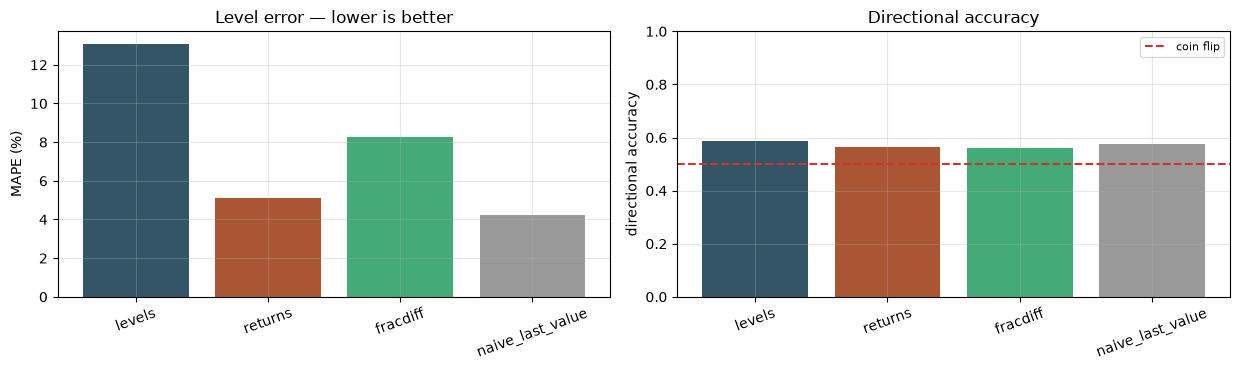

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 3.8))
order = [*ARMS, "naive_last_value"]
colours = ["#356", "#a53", "#4a7", "#999"]

a1.bar(order, accuracy.loc[order, "mape"], color=colours)
a1.set_ylabel("MAPE (%)"); a1.set_title("Level error — lower is better")
a1.tick_params(axis="x", rotation=20)

da = accuracy.loc[order, "directional_accuracy"]
a2.bar(order, da.fillna(0), color=colours)
a2.axhline(0.5, c="#c33", ls="--", lw=1.5, label="coin flip")
a2.set_ylabel("directional accuracy"); a2.set_ylim(0, 1)
a2.set_title("Directional accuracy"); a2.tick_params(axis="x", rotation=20); a2.legend(fontsize=8)
for i, value in enumerate(da):
    if np.isnan(value):
        a2.text(i, 0.02, "undefined\n(flat)", ha="center", fontsize=7, color="#333")
plt.tight_layout(); plt.show()

In [7]:
pivot = errors_df.pivot(index="symbol", columns="arm", values="directional_accuracy")[ARMS]
print("Directional accuracy by stock:")
print(pivot.round(3).to_string())
print("\nBest arm per stock:")
print(pivot.idxmax(axis=1).value_counts().to_string())

se = 0.5 / np.sqrt(len(test_index))
print(f"\nWith {len(test_index)} test months the standard error on a directional-accuracy")
print(f"estimate is about {se:.3f}, so gaps below roughly {2 * se:.2f} are not")
print("distinguishable from noise on a single stock.")

Directional accuracy by stock:
arm         levels  returns  fracdiff
symbol                               
HDFCB_IN     0.743    0.657     0.714
ICICIBC_IN   0.543    0.486     0.486
INFO_IN      0.514    0.486     0.457
RIL_IN       0.429    0.486     0.429
TCS_IN       0.714    0.714     0.714

Best arm per stock:
levels     4
returns    1

With 36 test months the standard error on a directional-accuracy
estimate is about 0.083, so gaps below roughly 0.17 are not
distinguishable from noise on a single stock.


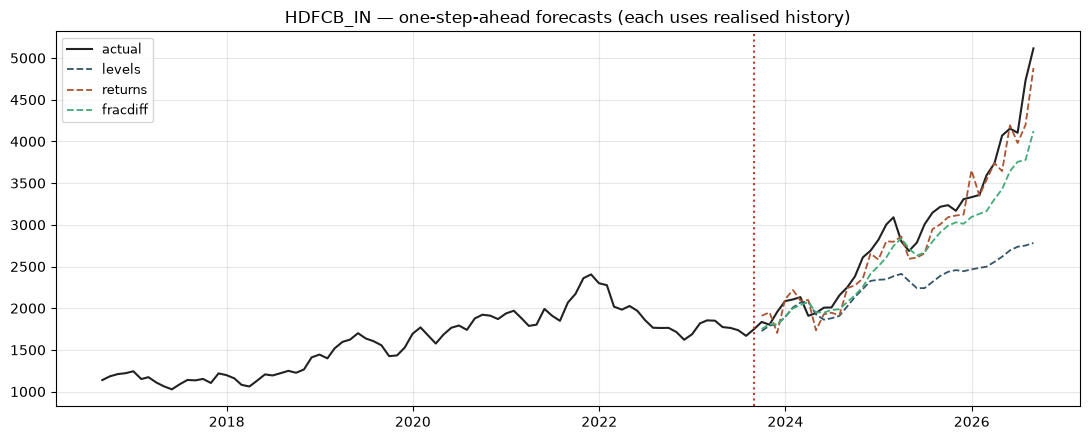

In [8]:
symbol = monthly.columns[0]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly[symbol].to_numpy(), color="#222", lw=1.5, label="actual")
for arm, colour in zip(ARMS, ["#356", "#a53", "#4a7"]):
    if symbol in forecasts[arm]:
        f = forecasts[arm][symbol]
        ax.plot(f.index, f.to_numpy(), lw=1.3, ls="--", color=colour, label=f"{arm}")
ax.axvline(split_at, c="#c33", ls=":", lw=1.5)
ax.set_title(f"{symbol} — one-step-ahead forecasts (each uses realised history)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. From forecast to position

`expected_returns` converts a price forecast into the predicted one-period return,
which is the quantity a portfolio layer can act on. Weights are proportional to
positive expected return, capped at 40% per name.

The cap matters. Without it a single positive forecast takes the whole book. When the
cap cannot be satisfied — one positive signal under a 40% cap — the residual stays in
**cash** rather than being forced back into the capped position.

In [9]:
expected = {
    arm: pd.DataFrame(
        {symbol: expected_returns(f, monthly[symbol]) for symbol, f in forecasts[arm].items()}
    ).reindex(test_index).dropna(how="all")
    for arm in ARMS
}

for arm in ARMS:
    frame = expected[arm]
    print(f"{arm:>9}: {frame.shape[0]} periods, mean predicted return "
          f"{frame.stack().mean():+.4f}, sd {frame.stack().std():.4f}")

   levels: 36 periods, mean predicted return -0.1099, sd 0.0965
  returns: 36 periods, mean predicted return +0.0090, sd 0.0411
 fracdiff: 36 periods, mean predicted return -0.0300, sd 0.0820


In [10]:
cost_model = default_cost_model()
print(f"Delivery round trip: {cost_model.round_trip_bps():.2f} bps, "
      f"charged on one-way turnover each month.\n")

backtests = {
    arm: backtest_signals(
        monthly, expected[arm], mode="long_only",
        max_weight=MAX_WEIGHT, cost_model=cost_model,
    )
    for arm in ARMS
}

# Control: equal weight over the same periods, paying the same cost model.
equal_expected = pd.DataFrame(1.0, index=expected[ARMS[0]].index, columns=monthly.columns)
backtests["equal_weight"] = backtest_signals(
    monthly, equal_expected, mode="equal", cost_model=cost_model,
)
print(f"{len(backtests)} portfolios backtested over {len(expected[ARMS[0]])} months")

Delivery round trip: 26.96 bps, charged on one-way turnover each month.

4 portfolios backtested over 36 months


## 6. Performance

Gross and net are both reported. The gap is the cost drag, and on a monthly-rebalanced
Indian delivery book it is not a rounding error.

In [11]:
summary = pd.DataFrame(
    {name: bt.summary(PERIODS_PER_YEAR, RISK_FREE) for name, bt in backtests.items()}
).T
summary[[
    "gross_total_return", "net_total_return", "gross_cagr", "net_cagr",
    "gross_volatility", "gross_sharpe", "net_sharpe", "net_max_drawdown",
    "mean_turnover", "total_costs", "cost_drag", "hit_rate",
]].round(4)

,gross_total_return,net_total_return,gross_cagr,net_cagr,gross_volatility,gross_sharpe,net_sharpe,net_max_drawdown,mean_turnover,total_costs,cost_drag,hit_rate
levels,0.3308,0.3254,0.1029,0.1014,0.0759,0.4756,0.4576,-0.0312,0.0955,0.0046,0.0054,0.3611
returns,0.4586,0.4428,0.1382,0.1339,0.1044,0.6740,0.6371,-0.1383,0.2392,0.0116,0.0158,0.6944
fracdiff,0.1717,0.1614,0.0558,0.0526,0.0970,-0.0619,-0.0940,-0.1745,0.1991,0.0097,0.0104,0.5833
equal_weight,0.5103,0.5103,0.1519,0.1519,0.0926,0.8782,0.8782,-0.0955,0.0139,0.0007,-0.0000,0.7222


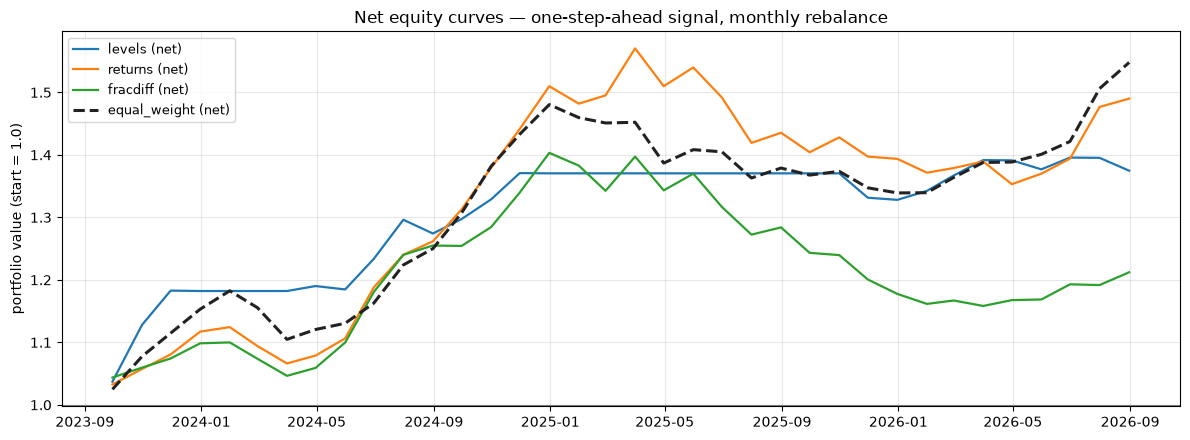

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, bt in backtests.items():
    style = {"lw": 2.2, "color": "#222", "ls": "--"} if name == "equal_weight" else {"lw": 1.6}
    ax.plot(bt.equity.index, bt.equity["net"].to_numpy(), label=f"{name} (net)", **style)
ax.axhline(1.0, c="grey", lw=0.8)
ax.set_title("Net equity curves — one-step-ahead signal, monthly rebalance")
ax.set_ylabel("portfolio value (start = 1.0)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

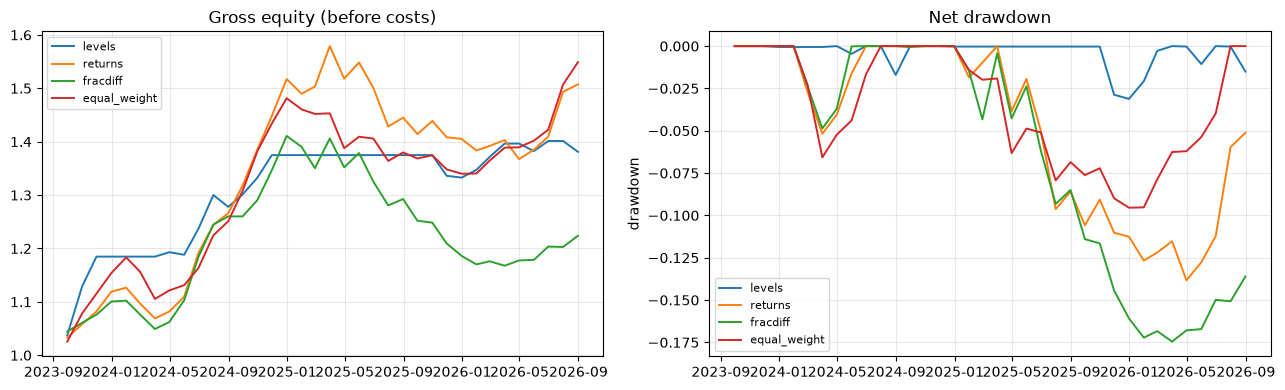

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, bt in backtests.items():
    axes[0].plot(bt.equity.index, bt.equity["gross"].to_numpy(), lw=1.4, label=name)
    drawdown = bt.equity["net"] / bt.equity["net"].cummax() - 1.0
    axes[1].plot(drawdown.index, drawdown.to_numpy(), lw=1.4, label=name)
axes[0].set_title("Gross equity (before costs)"); axes[0].legend(fontsize=8)
axes[1].set_title("Net drawdown"); axes[1].set_ylabel("drawdown"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

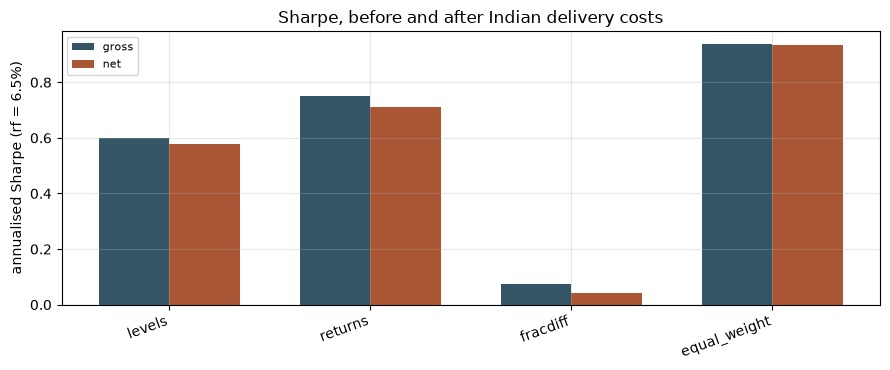

              gross_sharpe  net_sharpe  project_sharpe_net
levels               0.598       0.579               2.472
returns              0.750       0.711               2.316
fracdiff             0.073       0.040               1.217
equal_weight         0.936       0.934               2.846

project_sharpe_net reproduces the Stock-Portfolio-Optimiser formula, which scales
by sqrt(number of observations) rather than periods per year. It is comparable
within this study but not against a conventionally annualised Sharpe.


In [14]:
sharpes = pd.DataFrame({
    "gross_sharpe": {n: annualised_sharpe(b.gross_returns, PERIODS_PER_YEAR, RISK_FREE)
                     for n, b in backtests.items()},
    "net_sharpe": {n: annualised_sharpe(b.net_returns, PERIODS_PER_YEAR, RISK_FREE)
                   for n, b in backtests.items()},
    "project_sharpe_net": {n: project_sharpe(b.net_returns * 100) for n, b in backtests.items()},
})

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(sharpes)); width = 0.35
ax.bar(x - width / 2, sharpes["gross_sharpe"], width, label="gross", color="#356")
ax.bar(x + width / 2, sharpes["net_sharpe"], width, label="net", color="#a53")
ax.axhline(0, c="grey", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(sharpes.index, rotation=20, ha="right")
ax.set_ylabel(f"annualised Sharpe (rf = {RISK_FREE:.1%})")
ax.set_title("Sharpe, before and after Indian delivery costs"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(sharpes.round(3).to_string())
print()
print("project_sharpe_net reproduces the Stock-Portfolio-Optimiser formula, which scales")
print("by sqrt(number of observations) rather than periods per year. It is comparable")
print("within this study but not against a conventionally annualised Sharpe.")

## 7. Where did the return come from?

Per-stock contribution sums to the gross return, which is what makes it an attribution
rather than a collection of statistics. Read it to find out whether a result is broad
or one name carrying everything — a portfolio whose return is 90% one stock has made
one bet, whatever its nominal breadth.

In [15]:
best_arm = max(ARMS, key=lambda a: backtests[a].summary(PERIODS_PER_YEAR, RISK_FREE)["net_sharpe"])
print(f"Best net Sharpe: {best_arm}\n")

contrib = attribution(backtests[best_arm])
print(f"Per-stock attribution — {best_arm}:")
contrib.round(4)

Best net Sharpe: returns

Per-stock attribution — returns:


,contribution,mean_weight,max_weight,periods_held,hit_rate,mean_return_when_held,share_of_gross
ICICIBC_IN,0.1904,0.2451,0.4,27,0.6296,0.0172,0.4448
HDFCB_IN,0.1424,0.1055,0.4,14,0.9286,0.0443,0.3325
TCS_IN,0.0682,0.2067,0.4,28,0.6786,0.0141,0.1593
RIL_IN,0.0350,0.1192,0.4,18,0.5556,0.0171,0.0818
INFO_IN,-0.0078,0.2679,0.4,36,0.4444,-0.0027,-0.0183


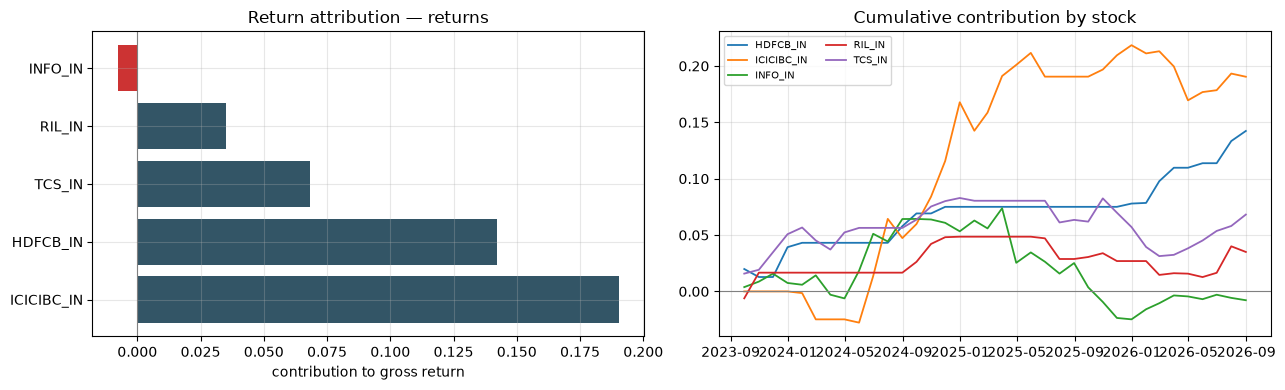

Largest single-stock share of gross return: 44.5%


In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
colours = ["#356" if v >= 0 else "#c33" for v in contrib["contribution"]]
a1.barh(contrib.index, contrib["contribution"], color=colours)
a1.axvline(0, c="grey", lw=0.8)
a1.set_xlabel("contribution to gross return"); a1.set_title(f"Return attribution — {best_arm}")

cumulative = backtests[best_arm].contributions.cumsum()
for column in cumulative.columns:
    a2.plot(cumulative.index, cumulative[column].to_numpy(), lw=1.3, label=column)
a2.axhline(0, c="grey", lw=0.8)
a2.set_title("Cumulative contribution by stock"); a2.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

top = contrib["share_of_gross"].abs().max()
print(f"Largest single-stock share of gross return: {top:.1%}")

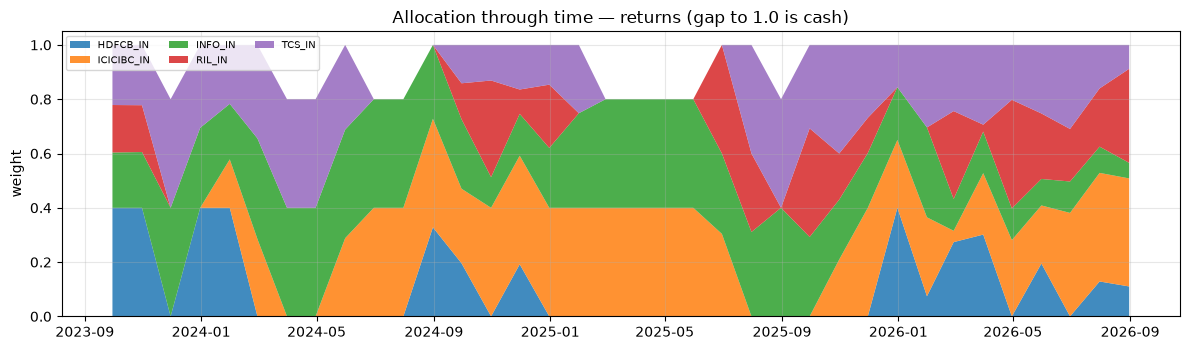

Mean invested fraction: 94.4%  (months fully in cash: 0 of 36)


In [17]:
fig, ax = plt.subplots(figsize=(12, 3.6))
weights = backtests[best_arm].weights
ax.stackplot(weights.index, *[weights[c].clip(lower=0) for c in weights.columns],
             labels=list(weights.columns), alpha=0.85)
ax.set_title(f"Allocation through time — {best_arm} (gap to 1.0 is cash)")
ax.set_ylabel("weight"); ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

invested = weights.sum(axis=1)
print(f"Mean invested fraction: {invested.mean():.1%}  "
      f"(months fully in cash: {(invested < 1e-9).sum()} of {len(invested)})")

## 8. Component decomposition

`net = equal-weight baseline + selection effect − costs`

The **selection effect** is the part attributable to deviating from equal weight, and
it is the only component a forecast can claim credit for. The baseline is what any
investor gets for free. Reporting them separately is what stops a rising market from
being mistaken for a working model.

In [18]:
decomposition = pd.DataFrame(
    {arm: decompose_vs_equal_weight(backtests[arm], backtests["equal_weight"]) for arm in ARMS}
).T
decomposition.round(4)

,equal_weight_baseline,gross_strategy,selection_effect,total_costs,net_strategy,selection_per_period,selection_t_stat,equal_weight_net
levels,0.5489,0.3810,-0.1680,0.0046,0.3747,-0.0033,-0.8376,0.5479
returns,0.5489,0.5073,-0.0416,0.0116,0.4900,-0.0007,-0.2358,0.5479
fracdiff,0.5489,0.2238,-0.3251,0.0097,0.2122,-0.0066,-1.7664,0.5479


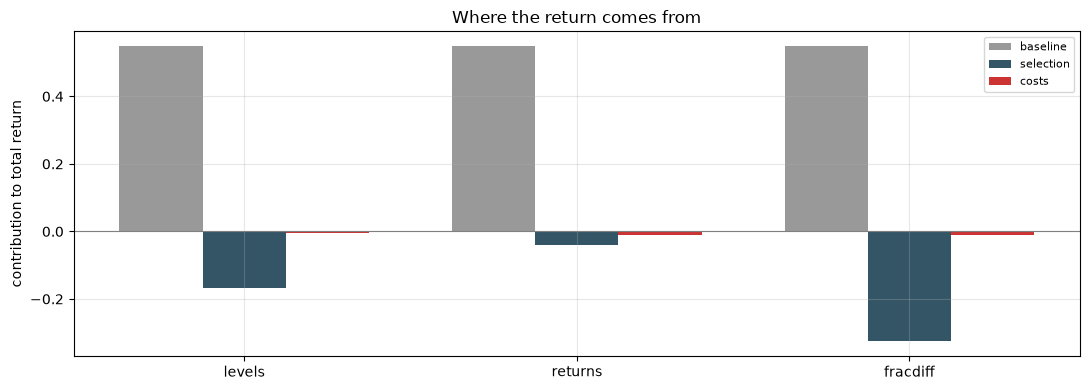

Selection effect and its t-statistic:
     levels: -0.1680  t = -0.84
    returns: -0.0416  t = -0.24
   fracdiff: -0.3251  t = -1.77

With 36 monthly observations, |t| under about 2.0 is not
evidence of anything. Read these as a template for the real data run.


In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(ARMS)); width = 0.25
ax.bar(x - width, decomposition["equal_weight_baseline"], width, label="baseline", color="#999")
ax.bar(x, decomposition["selection_effect"], width, label="selection", color="#356")
ax.bar(x + width, -decomposition["total_costs"], width, label="costs", color="#c33")
ax.axhline(0, c="grey", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ARMS)
ax.set_ylabel("contribution to total return")
ax.set_title("Where the return comes from"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Selection effect and its t-statistic:")
for arm in ARMS:
    row = decomposition.loc[arm]
    print(f"  {arm:>9}: {row['selection_effect']:+.4f}  t = {row['selection_t_stat']:+.2f}")
print()
print(f"With {len(test_index)} monthly observations, |t| under about 2.0 is not")
print("evidence of anything. Read these as a template for the real data run.")

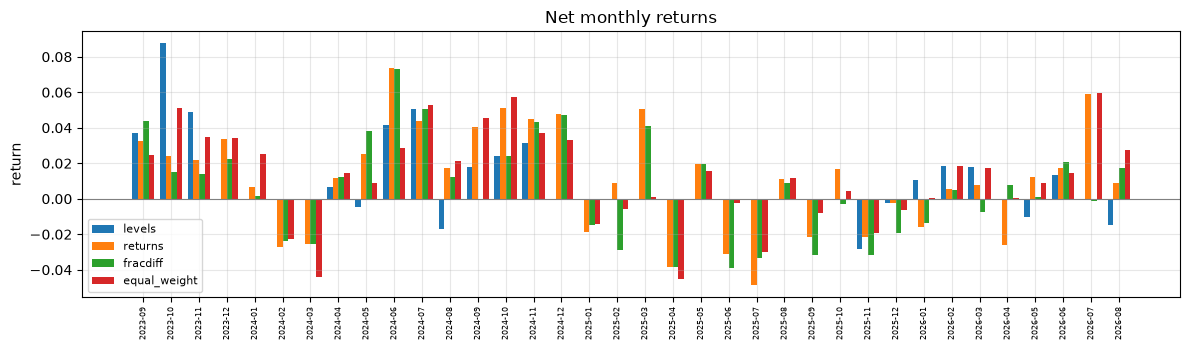

Net monthly return distribution:
                mean     std     min     max
levels        0.0091  0.0221 -0.0285  0.0875
returns       0.0116  0.0300 -0.0487  0.0738
fracdiff      0.0057  0.0283 -0.0389  0.0734
equal_weight  0.0125  0.0264 -0.0449  0.0595


In [20]:
monthly_returns = pd.DataFrame({name: bt.net_returns for name, bt in backtests.items()})

# Plot against positional x: a DatetimeIndex bar plot needs an explicit freq in
# pandas 3 and errors without one.
fig, ax = plt.subplots(figsize=(12, 3.6))
positions = np.arange(len(monthly_returns))
width = 0.8 / monthly_returns.shape[1]
for offset, column in enumerate(monthly_returns.columns):
    ax.bar(positions + offset * width, monthly_returns[column].to_numpy(), width, label=column)
ax.set_xticks(positions + 0.4 - width / 2)
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_returns.index], rotation=90, fontsize=6)
ax.axhline(0, c="grey", lw=0.8)
ax.set_title("Net monthly returns"); ax.set_ylabel("return"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Net monthly return distribution:")
print(monthly_returns.describe().T[["mean", "std", "min", "max"]].round(4).to_string())

## 9. Sensitivity: does the conclusion survive small changes?

A result that flips when the cap moves from 40% to 50%, or when execution is delayed by
one period, was never a result. This is the cheapest robustness check available and it
disqualifies a lot of apparent findings.

In [21]:
sensitivity = []
for arm in ARMS:
    for mode in ("long_only", "long_short"):
        for cap in (0.3, 0.4, 1.0):
            for lag in (0, 1):
                bt = backtest_signals(
                    monthly, expected[arm], mode=mode, max_weight=cap,
                    cost_model=cost_model, lag=lag,
                )
                sensitivity.append({
                    "arm": arm, "mode": mode, "max_weight": cap, "lag": lag,
                    "net_sharpe": annualised_sharpe(bt.net_returns, PERIODS_PER_YEAR, RISK_FREE),
                    "net_return": float((1 + bt.net_returns).prod() - 1),
                })
sens = pd.DataFrame(sensitivity)
print("Net Sharpe across settings:")
print(sens.pivot_table(index=["arm", "mode"], columns=["max_weight", "lag"],
                       values="net_sharpe").round(3).to_string())

Net Sharpe across settings:
max_weight             0.3           0.4           1.0       
lag                      0      1      0      1      0      1
arm      mode                                                
fracdiff long_only  -0.108 -0.721  0.040 -0.492  0.419 -0.138
         long_short -1.399 -2.062 -1.487 -1.932 -1.462 -1.789
levels   long_only   0.330  0.617  0.579  0.918  0.858  1.329
         long_short -0.494 -0.576 -0.652 -0.631 -0.681 -0.563
returns  long_only   0.561  0.543  0.711  0.625  0.867  0.519
         long_short -1.127 -0.746 -1.030 -0.767 -0.713 -0.549


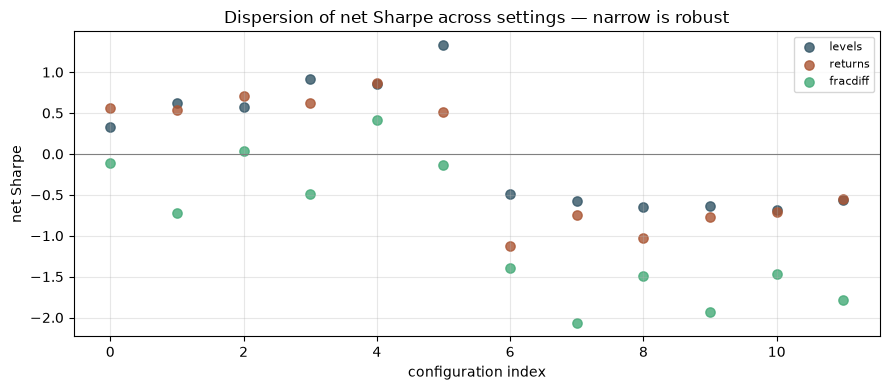

Spread of net Sharpe within each arm:
           mean    std    min    max
arm                                 
fracdiff -0.928  0.860 -2.062  0.419
levels    0.086  0.755 -0.681  1.329
returns  -0.092  0.781 -1.127  0.867


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
for arm, colour in zip(ARMS, ["#356", "#a53", "#4a7"]):
    subset = sens[sens["arm"] == arm]
    ax.scatter(range(len(subset)), subset["net_sharpe"], label=arm, color=colour, s=45, alpha=0.8)
ax.axhline(0, c="grey", lw=0.8)
ax.set_xlabel("configuration index"); ax.set_ylabel("net Sharpe")
ax.set_title("Dispersion of net Sharpe across settings — narrow is robust")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Spread of net Sharpe within each arm:")
print(sens.groupby("arm")["net_sharpe"].agg(["mean", "std", "min", "max"]).round(3).to_string())

## Takeaways

1. **One-step-ahead is the only forecast a strategy can trade.** Each prediction uses
   realised history through the previous period. Recursive multi-step charts describe a
   harder, different, and untradeable problem.

2. **Directional accuracy first, RMSE second.** An LSTM on price levels can post a good
   RMSE by echoing the last value. The naive last-value benchmark makes that visible —
   its directional accuracy is undefined, because a flat forecast expresses no view.

3. **Fractional differencing must be chosen per series.** `d` and the memory it costs
   both vary across the universe; a single global `d` over- or under-differences most
   names. Arms B and C are inverted exactly back to price space, so the comparison is
   like for like.

4. **Decompose the return.** `baseline + selection − costs` separates what the forecast
   earned from what the market handed over. The selection effect is usually far smaller
   than the baseline, and its t-statistic is usually far below 2.

5. **Costs and the weight cap are part of the strategy.** Monthly rebalancing on Indian
   delivery pays roughly 23 bps of round-trip cost on turnover, and an uncapped
   Roy-style allocation will put the whole book in one name.

### Next steps

- Rerun on real Bloomberg data; every number here comes from a random walk.
- Widen to the full point-in-time NIFTY membership and lengthen the history.
- Refit periodically (`refit_every`) so the model sees regime change.
- Compare against the classification framing in notebook **04**, which replaces RMSE
  with triple-barrier labels and purged cross-validation.